In [ ]:
"""
Used to mount to drive and upload a zip file to later extract it.
""""
from google.colab import drive
drive.mount('/content/drive')

import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/fruits_20_clean.zip', 'r') as z:
    z.extractall('/content/fruits')

Mounted at /content/drive


Number of classes: 20
Classes: ['Apple Granny Smith 1', 'Apple Red 1', 'Avocado 1', 'Banana 1', 'Blueberry 1', 'Cherry 1', 'Cocos 1', 'Grape Blue 1', 'Kiwi 1', 'Lemon 1', 'Mango 1', 'Orange 1', 'Papaya 1', 'Peach 1', 'Pear 1', 'Pineapple 1', 'Pomegranate 1', 'Raspberry 1', 'Strawberry 1', 'Watermelon 1']


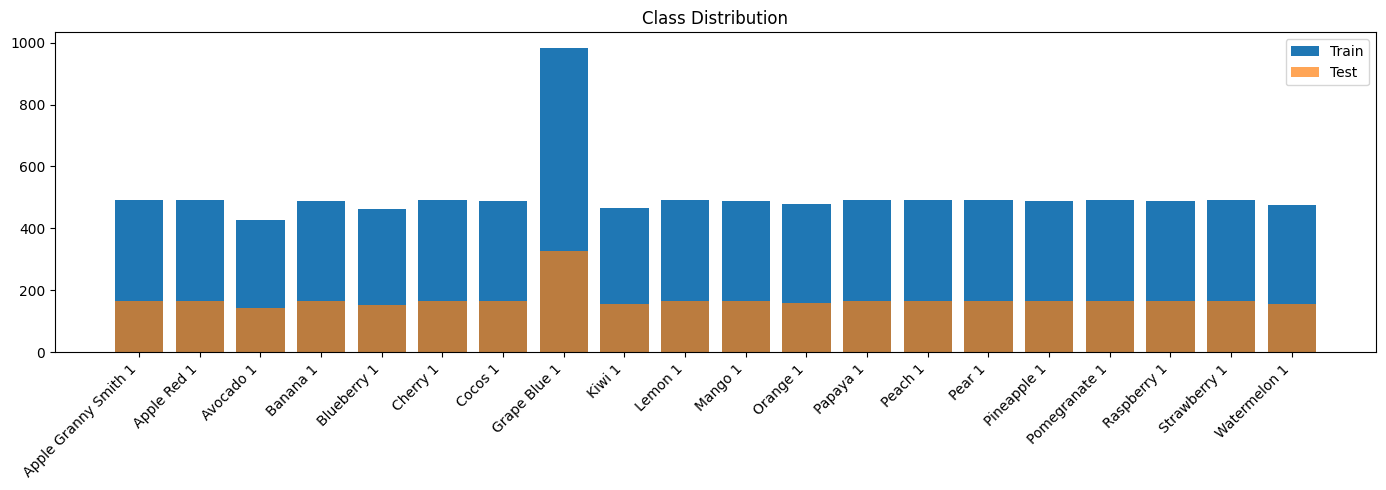

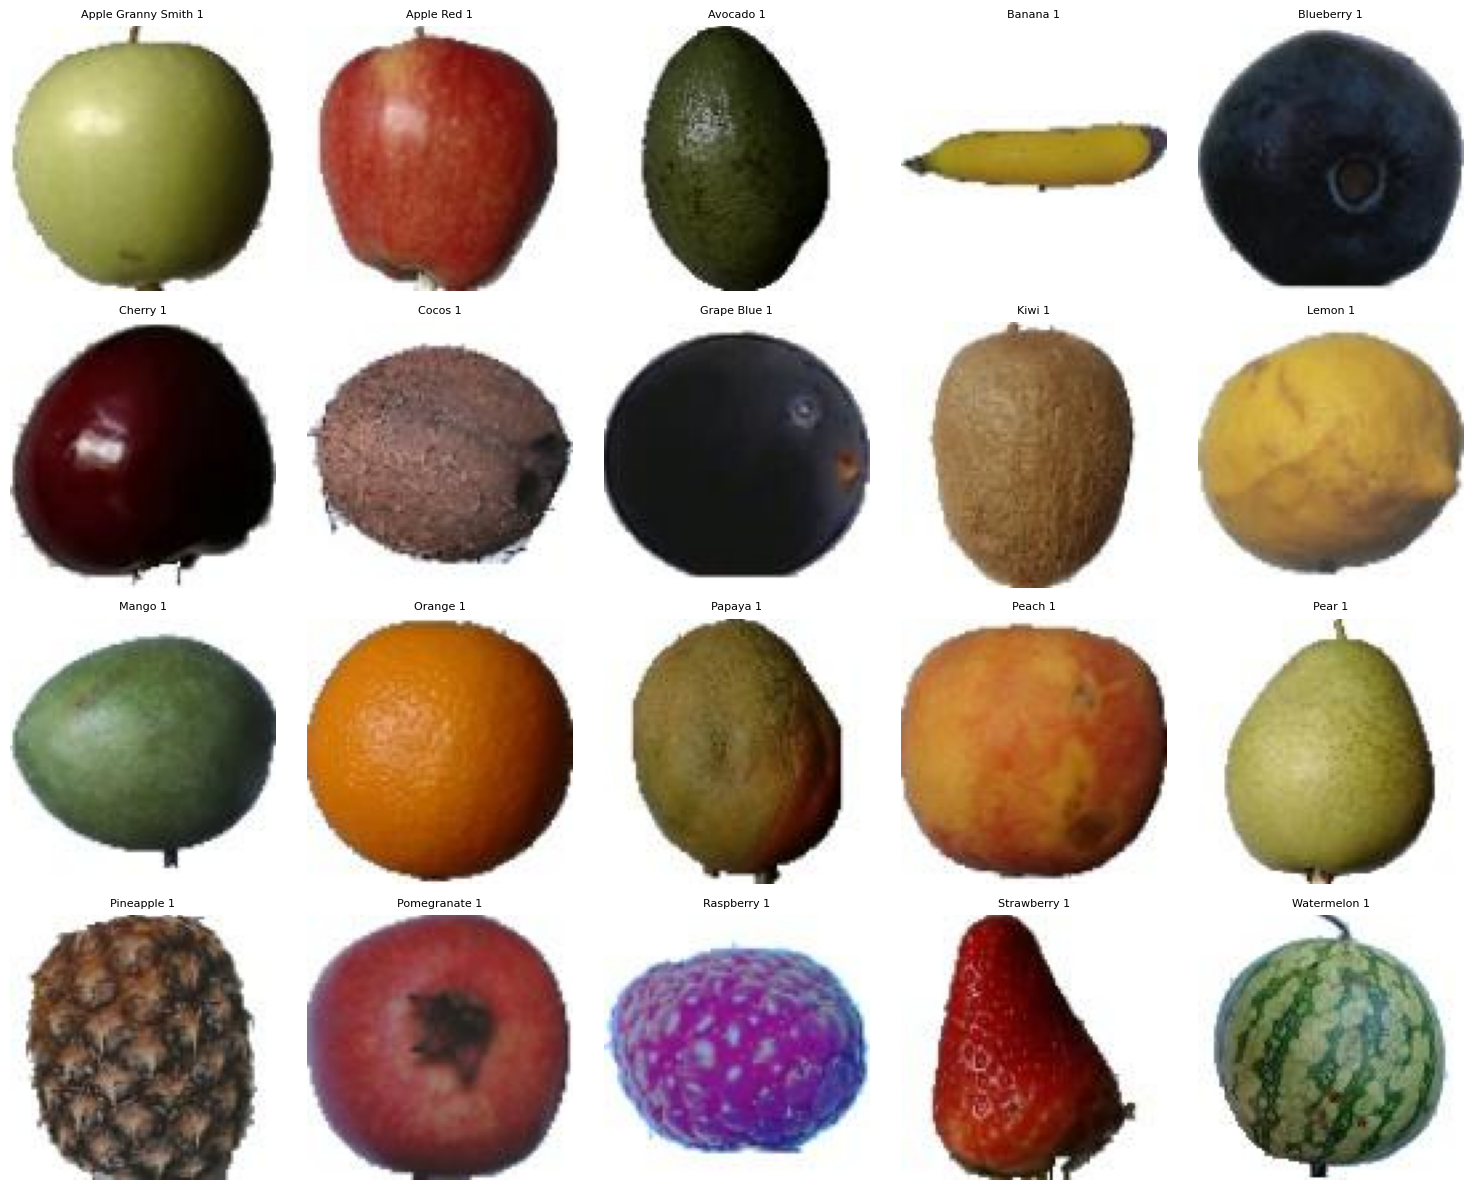

In [ ]:
"""
This is to perform EDA. Explores dataset and places them in key:value pairs
and later build a barchart to show.

From each classes it notes the amount of fruit images present there.

"""
import os, matplotlib.pyplot as plt, numpy as np
from PIL import Image
from collections import Counter

train_dir = '/content/fruits/Training'
test_dir  = '/content/fruits/Test'

classes = sorted(os.listdir(train_dir))
print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}")

train_counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in classes}
test_counts  = {c: len(os.listdir(os.path.join(test_dir,  c))) for c in classes}

plt.figure(figsize=(14,5))
plt.bar(train_counts.keys(), train_counts.values(), label='Train')
plt.bar(test_counts.keys(),  test_counts.values(),  label='Test', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend(); plt.title("Class Distribution"); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for ax, cls in zip(axes.flatten(), classes):
    img_path = os.path.join(train_dir, cls, os.listdir(os.path.join(train_dir, cls))[0])
    ax.imshow(Image.open(img_path))
    ax.set_title(cls, fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
"""
It prepares the data for training. It makes the images of same size through pixels.

Also it now divides the data into three parts test, train and validate.
"""

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (100,100)
BATCH_SIZE = 32  #how many images AI will look at in one time

datagen = ImageDataGenerator(
    rescale=1./255,  #This is normalization as it performs well with small scale.
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,  # Helps detect overfitting in a model.
    class_mode='categorical',
    subset='validation'
)

test_data = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(classes)

Found 8143 images belonging to 20 classes.
Found 2028 images belonging to 20 classes.
Found 3404 images belonging to 20 classes.


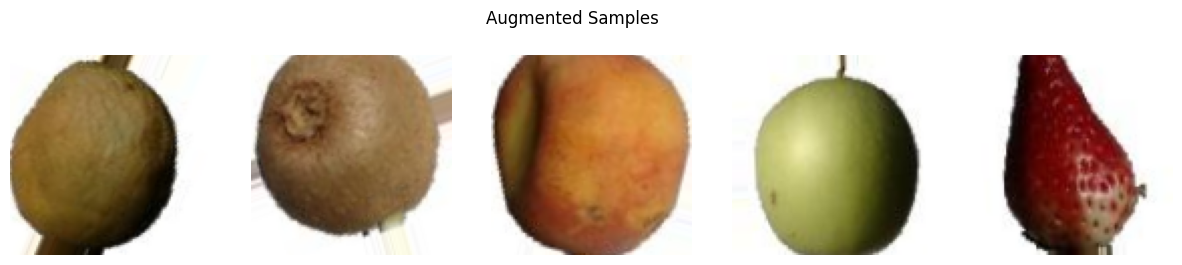

In [ ]:
#Grabs the next batch for training and also tells you that the data augumentation is working.
sample_batch = next(train_data)
fig, axes = plt.subplots(1, 5, figsize=(15,3))
for ax, img in zip(axes, sample_batch[0][:5]):
    ax.imshow(img); ax.axis('off')
plt.suptitle("Augmented Samples"); plt.show()

In [ ]:
"""
The baseline CNN consists of three convolutional layers with increasing filter sizes (32, 64, 128),
each followed by max pooling layers to reduce spatial dimensions.
The flattened output is passed through three fully connected dense layers (256, 128, 64) to learn high-level features.
Finally, a softmax layer outputs probabilities for each class in the dataset.

This architecture is relatively simple and serves as a reference model to compare with deeper and more advanced architectures.

"""
from tensorflow.keras import layers, models

def build_baseline(): # Creates a model.
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)), #Scans the image and detects edges and textures.
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2), # Skinks the image by taking maximum value
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')  # output layer
    ])
    return model

baseline = build_baseline()
baseline.summary()

baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_baseline = baseline.fit(
    train_data,
    epochs=20,
    validation_data=val_data
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,412,756 (13.02 MB)

 Trainable params: 3,412,756 (13.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 40s 145ms/step - accuracy: 0.7916 - loss: 0.6446 - val_accuracy: 0.9231 - val_loss: 0.2244
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 32s 127ms/step - accuracy: 0.9565 - loss: 0.1462 - val_accuracy: 0.9196 - val_loss: 0.2566
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 32s 127ms/step - accuracy: 0.9805 - loss: 0.0585 - val_accuracy: 0.9635 - val_loss: 0.0910
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 38s 148ms/step - accuracy: 0.9735 - loss: 0.0777 - val_accuracy: 0.9931 - val_loss: 0.0235
Epoch 5/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 32s 125ms/step - accuracy: 0.9939 - loss: 0.0196 - val_accuracy: 0.9610 - val_loss: 0.0935
Epoch 6/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 32s 126ms/step - accuracy: 0.9765 - loss: 0.0700 - val_accuracy: 0.9847 - val_loss: 0.0490
Epoch 7/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.9937 - loss: 0.0181 - val_accuracy: 0.9985 - val_loss: 0.0071
Epoch 8/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 32s 126ms/step - accuracy: 0.9882 - loss: 0

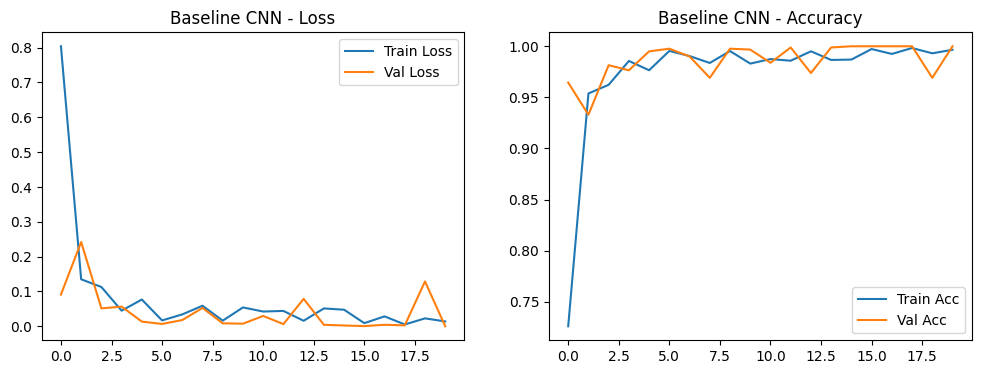

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy'); plt.legend()
    plt.show()

plot_history(history_baseline, "Baseline CNN")

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step
                      precision    recall  f1-score   support

Apple Granny Smith 1       0.95      1.00      0.98       164
         Apple Red 1       1.00      1.00      1.00       164
           Avocado 1       1.00      1.00      1.00       143
            Banana 1       1.00      1.00      1.00       166
         Blueberry 1       1.00      0.84      0.91       154
            Cherry 1       1.00      1.00      1.00       164
             Cocos 1       1.00      1.00      1.00       166
        Grape Blue 1       0.93      1.00      0.96       328
              Kiwi 1       1.00      1.00      1.00       156
             Lemon 1       1.00      1.00      1.00       164
             Mango 1       1.00      1.00      1.00       166
            Orange 1       1.00      1.00      1.00       160
            Papaya 1       1.00      1.00      1.00       164
             Peach 1       1.00      1.00      1.00       164
              Pear 1       

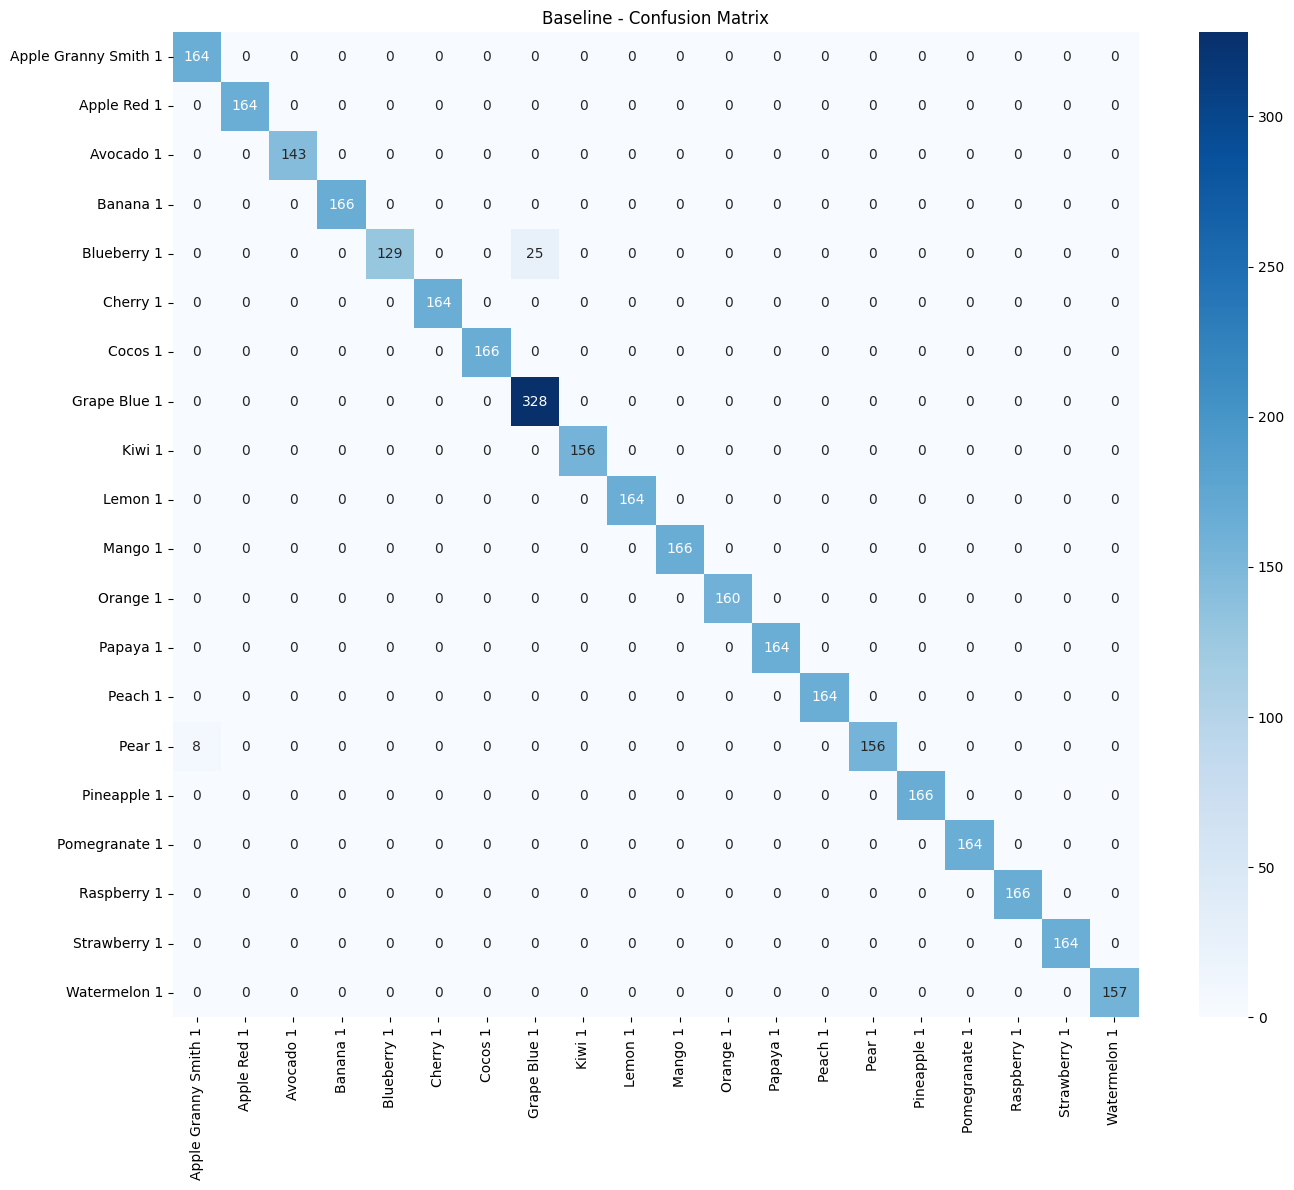

In [ ]:
"""
It evaluates the baseline model's performance on completely unseen test images.

It makes predictions, compares them to the real answers and presents the results in two ways
a classification report and a confusion matrix heatmap.
"""
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_data.reset() #remembers where they left off.

pred_probs = baseline.predict(test_data)
y_pred = np.argmax(pred_probs, axis=1) # Converts probabilities into a single predicted class number per image.

y_true = test_data.classes

print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred) # Compare true value and predicted value

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    xticklabels=classes,
    yticklabels=classes,
    annot=True,
    fmt='d',
    cmap='Blues' #the more the dark the colour the higher it is
)

plt.title("Baseline - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
"""
The deeper CNN architecture extends the baseline model by increasing the number of convolutional layers and filters.
Each block contains two convolutional layers followed by batch normalization, max pooling, and dropout for regularization.

Batch normalization helps stabilize and speed up training, while dropout reduces overfitting.
The model progressively learns more complex features through deeper layers (32 → 64 → 128 → 256 filters),
making it more suitable for complex image classification tasks.
"""

from tensorflow.keras.layers import BatchNormalization, Dropout

def build_deeper():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(100,100,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.MaxPooling2D(2,2),

        Dropout(0.25),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.MaxPooling2D(2,2),
        Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.MaxPooling2D(2,2),
        Dropout(0.25),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        layers.MaxPooling2D(2,2),
        Dropout(0.25),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        layers.Dense(256, activation='relu'),
        Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

deeper = build_deeper()
deeper.summary()
deeper.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 6,031,796 (23.01 MB)

 Trainable params: 6,029,812 (23.00 MB)

 Non-trainable params: 1,984 (7.75 KB)

Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 36s 139ms/step - accuracy: 0.9725 - loss: 0.1207 - val_accuracy: 0.9689 - val_loss: 0.1120
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 39s 155ms/step - accuracy: 0.9636 - loss: 0.1519 - val_accuracy: 0.6588 - val_loss: 7.2524
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 35s 137ms/step - accuracy: 0.9737 - loss: 0.0969 - val_accuracy: 0.9803 - val_loss: 0.1069
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 37s 145ms/step - accuracy: 0.9815 - loss: 0.0666 - val_accuracy: 0.9965 - val_loss: 0.0099
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 34s 133ms/step - accuracy: 0.9903 - loss: 0.0359 - val_accuracy: 0.9773 - val_loss: 0.0695
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 36s 139ms/step - accuracy: 0.9897 - loss: 0.0381 - val_accuracy: 0.9832 - val_loss: 0.0427
Epoch 7/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.9844 - loss: 0.0575 - val_accuracy: 0.9241 - val_loss: 0.2960
Epoch 8/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 36s 141ms/step - accuracy: 0.9402 - loss: 0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 56s 181ms/step - accuracy: 0.3354 - loss: 2.3304 - val_accuracy: 0.1085 - val_loss: 4.3609
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.5534 - loss: 1.3436 - val_accuracy: 0.0971 - val_loss: 9.5323
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 36s 139ms/step - accuracy: 0.7419 - loss: 0.7478 - val_accuracy: 0.1312 - val_loss: 8.5961
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.8230 - loss: 0.4924 - val_accuracy: 0.1198 - val_loss: 11.6460
Epoch 5/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 36s 141ms/step - accuracy: 0.8820 - loss: 0.3484 - val_accuracy: 0.2125 - val_loss: 5.0869
Epoch 6/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 34s 135ms/step - accuracy: 0.9134 - loss: 0.2471 - val_accuracy: 0.5725 - val_loss: 2.5078
Epoch 7/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 39s 152ms/step - accuracy: 0.9412 - loss: 0.1836 - val_accuracy: 0.4522 - val_loss: 3.0311
Epoch 8/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 35s 136ms/step - accuracy: 0.9558 - loss: 

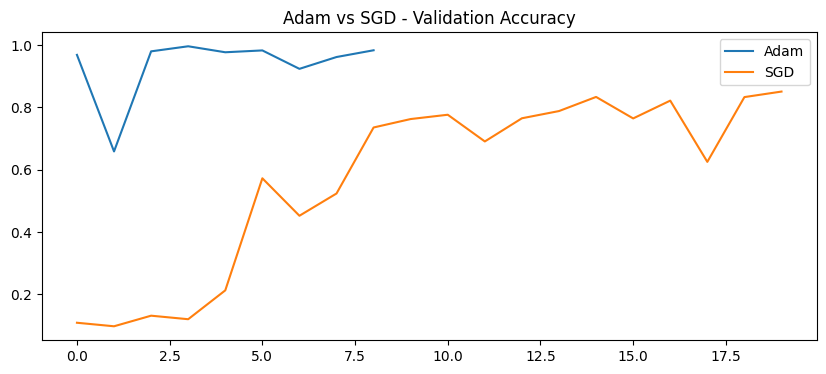

In [ ]:
"""
It compares two optimisers — Adam and SGD
by training the same deeper CNN architecture twice, once with each.

 Early Stopping is used to prevent wasted training time and overfitting.

"""
from tensorflow.keras.callbacks import EarlyStopping

# Fresh callback for fairness
es1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
es2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_deeper = deeper.fit(
    train_data,
    epochs=30,
    validation_data=val_data,
    callbacks=[es1]
)

deeper_sgd = build_deeper()

deeper_sgd.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = deeper_sgd.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[es2]
)

plt.figure(figsize=(10,4))

plt.plot(history_deeper.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')

plt.title("Adam vs SGD - Validation Accuracy")
plt.legend()
plt.show()

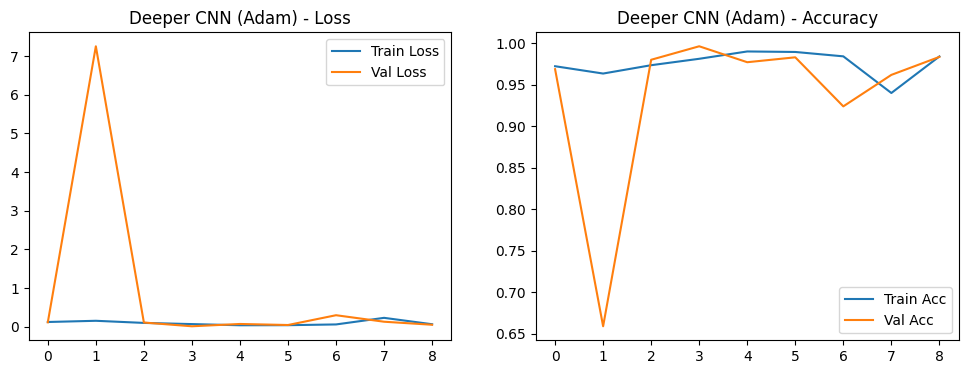

In [ ]:
plot_history(history_deeper, "Deeper CNN (Adam)")

In [ ]:
"""
It evaluates the deeper CNN model on unseen test images
resets the data runs predictions picks the most confident class per image
and prints a full report showing precision, recall and F1-score for every fruit type.

"""
test_data.reset()

pred_probs = deeper.predict(test_data)
y_pred_deep = np.argmax(pred_probs, axis=1)

y_true_deep = test_data.classes # Converts the probability arrays into a single predicted class number

print(classification_report(
    y_true_deep,
    y_pred_deep,
    target_names=classes
))

107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step
                      precision    recall  f1-score   support

Apple Granny Smith 1       1.00      1.00      1.00       164
         Apple Red 1       1.00      0.91      0.95       164
           Avocado 1       1.00      1.00      1.00       143
            Banana 1       1.00      1.00      1.00       166
         Blueberry 1       1.00      1.00      1.00       154
            Cherry 1       1.00      1.00      1.00       164
             Cocos 1       1.00      1.00      1.00       166
        Grape Blue 1       1.00      1.00      1.00       328
              Kiwi 1       1.00      1.00      1.00       156
             Lemon 1       1.00      1.00      1.00       164
             Mango 1       1.00      1.00      1.00       166
            Orange 1       1.00      1.00      1.00       160
            Papaya 1       1.00      1.00      1.00       164
             Peach 1       0.88      1.00      0.93       164
              Pear 1       

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


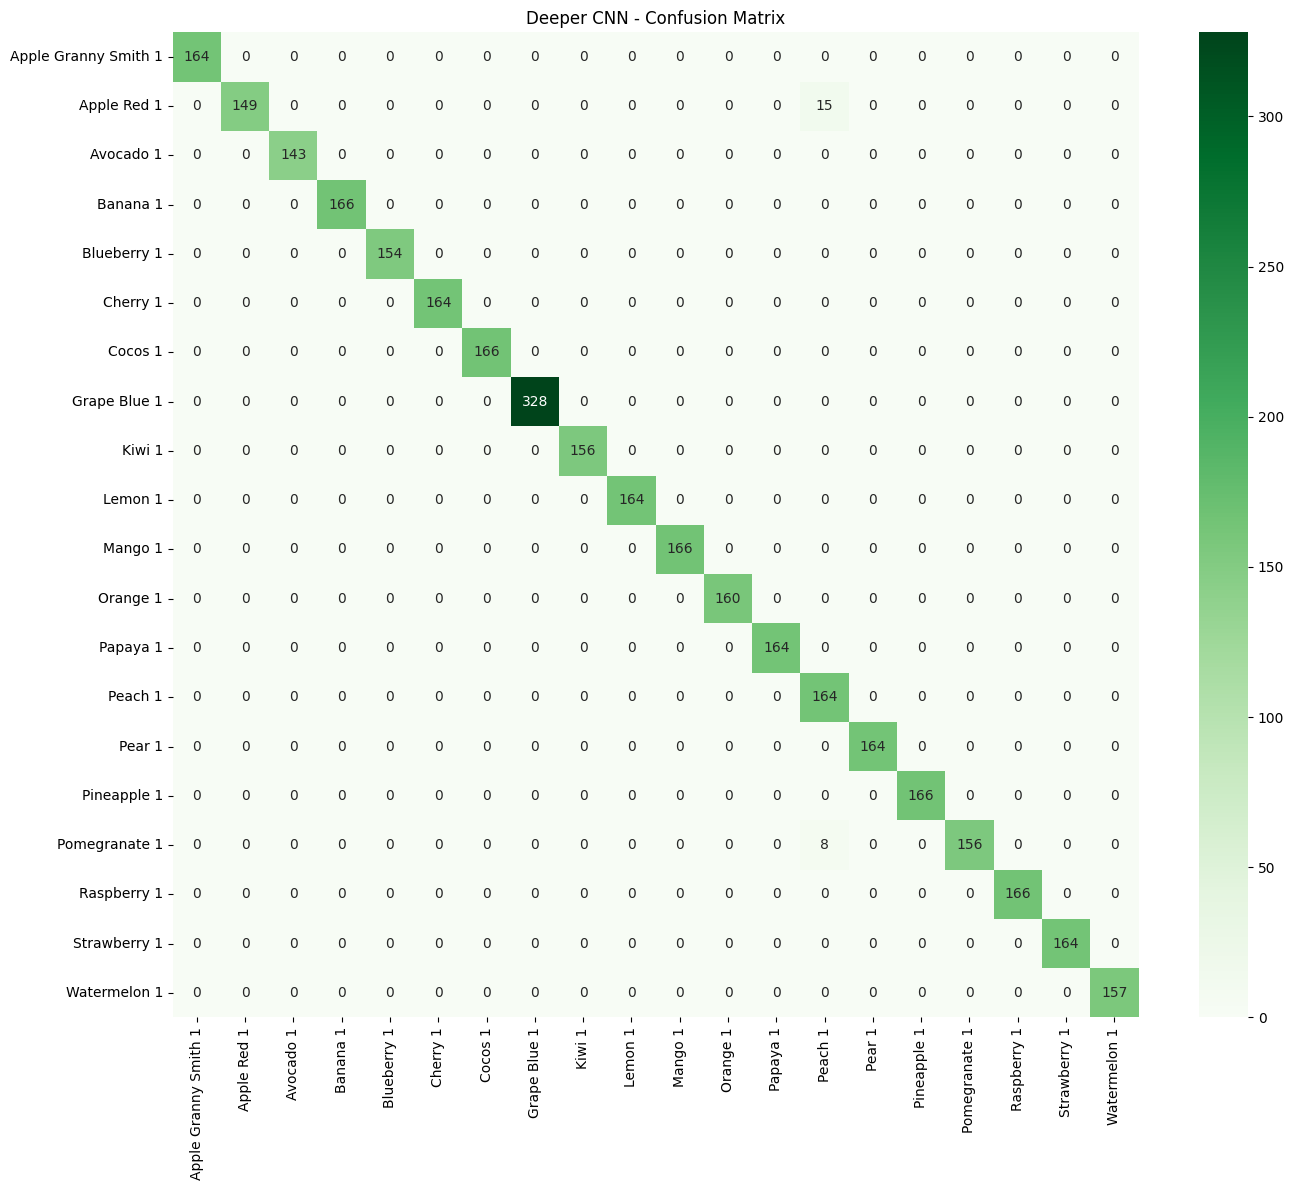

In [ ]:
test_data.reset()

pred_probs = deeper.predict(test_data)
y_pred_deep = np.argmax(pred_probs, axis=1)

y_true_deep = test_data.classes

cm_deep = confusion_matrix(y_true_deep, y_pred_deep)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm_deep,
    xticklabels=classes,
    yticklabels=classes,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Deeper CNN - Confusion Matrix")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


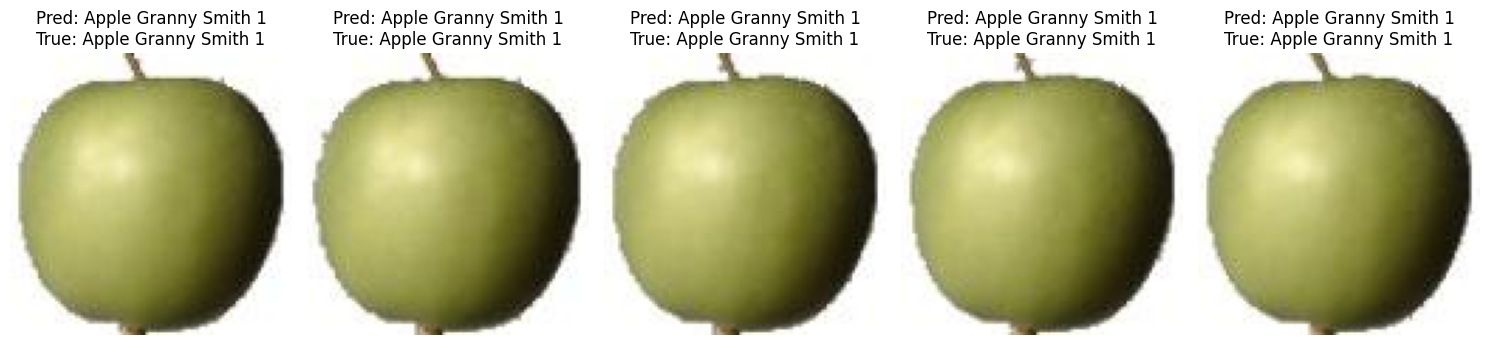

In [ ]:
"""
It visually spot-checks the deeper model's predictions by grabbing 5 test images
and displaying each one with its predicted label and true label as a title.
"""
test_data.reset()

images, labels = next(test_data)

predictions = deeper.predict(images)  # better than baseline

plt.figure(figsize=(15,8))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(images[i])

    pred_label = classes[np.argmax(predictions[i])]
    true_label = classes[np.argmax(labels[i])]

    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
"""
It builds a slightly crippled version of the deeper CNN
identical in every way except all Dropout layers have been surgically removed.
"""
def build_ablation():
    model = models.Sequential([

        layers.Conv2D(32,(3,3),activation='relu',padding='same',
                      input_shape=(100,100,3)),
        layers.Conv2D(32,(3,3),activation='relu',padding='same'),
        BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64,(3,3),activation='relu',padding='same'),
        layers.Conv2D(64,(3,3),activation='relu',padding='same'),
        BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128,(3,3),activation='relu',padding='same'),
        layers.Conv2D(128,(3,3),activation='relu',padding='same'),
        BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(256,(3,3),activation='relu',padding='same'),
        layers.Conv2D(256,(3,3),activation='relu',padding='same'),
        BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),

        layers.Dense(512,activation='relu'),
        BatchNormalization(),

        layers.Dense(256,activation='relu'),

        layers.Dense(NUM_CLASSES,activation='softmax')
    ])
    return model

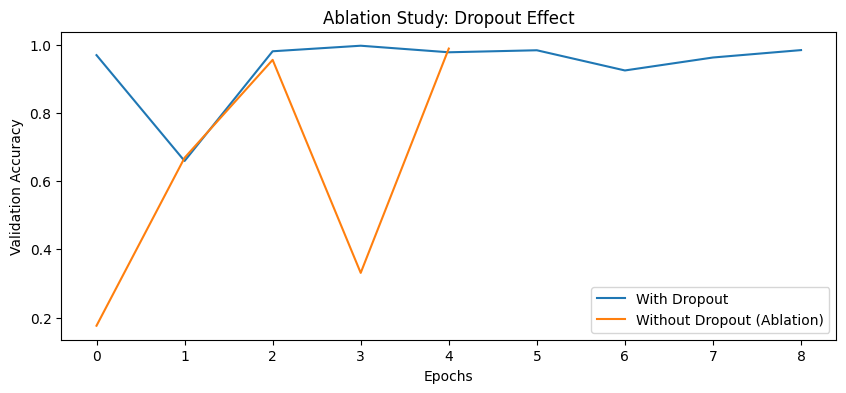

Deeper Model Accuracy: 0.9965482950210571
Ablation Model Accuracy: 0.9881656765937805


In [ ]:
plt.figure(figsize=(10,4))

plt.plot(history_deeper.history['val_accuracy'], label='With Dropout')
plt.plot(history_ablation.history['val_accuracy'], label='Without Dropout (Ablation)')

plt.title("Ablation Study: Dropout Effect")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.show()

print("Deeper Model Accuracy:", max(history_deeper.history['val_accuracy']))
print("Ablation Model Accuracy:", max(history_ablation.history['val_accuracy']))

/tmp/ipykernel_1804/2072060455.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 55s 182ms/step - accuracy: 0.9198 - loss: 0.2667 - val_accuracy: 0.9827 - val_loss: 0.0444
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 33s 129ms/step - accuracy: 0.9871 - loss: 0.0400 - val_accuracy: 0.9990 - val_loss: 0.0099
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 32s 126ms/step - accuracy: 0.9903 - loss: 0.0295 - val_accuracy: 0.9901 - val_loss: 0.0266
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 41s 127ms/step - accuracy: 0.9945 - loss: 0.0167 - val_accuracy: 0.9941 - val_loss: 0.0160
Epoch 5/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 36s 141ms/step - accuracy: 0.9929 - loss: 0.0212 - val_accuracy: 0.9956 - val_loss: 0.0104
Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 63s 185ms/step - accuracy: 0.8739 - loss: 0.4743 - val_accuracy: 0.9788 - val_loss: 0.0523
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 34s 134ms/step - accuracy: 0.9664 - loss: 0.1469 - val_accuracy: 0.9837 - val_loss: 0.0421
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 32s 127ms/step - accuracy: 0.9810 - loss: 0

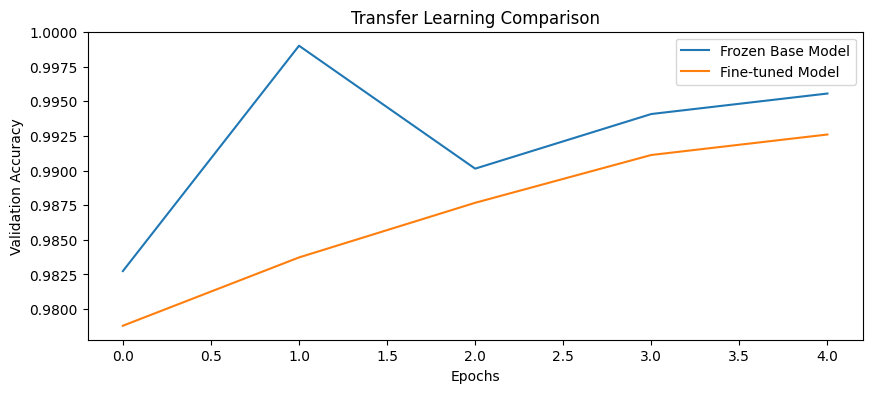

In [ ]:
"""
t implements Transfer Learning using MobileNetV2

First it freezes MobileNetV2 and trains only new custom layers
Then it carefully unfreezes the last 30 layers and fine-tunes them with a tiny learning rate.

"""
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model
from tensorflow.keras import layers

base_model = MobileNetV2(
    input_shape=(100,100,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False #Freezing the model.

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)

output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=output)

tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_tl = tl_model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[es]
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_tl_ft = tl_model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[es]
)

print("Transfer Learning (Frozen) Accuracy:",
      max(history_tl.history['val_accuracy']))

print("Transfer Learning (Fine-tuned) Accuracy:",
      max(history_tl_ft.history['val_accuracy']))

plt.figure(figsize=(10,4))

plt.plot(history_tl.history['val_accuracy'], label='Frozen Base Model')
plt.plot(history_tl_ft.history['val_accuracy'], label='Fine-tuned Model')

plt.title("Transfer Learning Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()